**CS500 - FOUNDATIONS OF ARTIFICIAL INTELLIGENCE (PROJECT - ML PIPELINE)**

**ML PIPELINE OVERVIEW:**

**STAGE 1: DATA LOADING & EXPLORATION**
Loaded the Kaggle credit card dataset containing 1.3 million training and 555K testing transactions with 22 features including transaction details, customer demographics, and merchant information. Performed exploratory data analysis to understand class imbalance (99% legitimate, 1% fraud), analyzed transaction amount distributions, identified fraud patterns across categories, and verified data quality with no missing values.


**STAGE 2: ADVANCED FEATURE ENGINEERING**
Engineered 31 features from the original 22 columns by creating temporal features (hour, day, month patterns), calculating geographic distance between customer and merchant using Haversine formula, analyzing spending behavior patterns (amount deviation and ratio from customer average), tracking merchant familiarity, extracting demographic features (age, gender), and encoding categorical variables using one-hot encoding for categories and target encoding for high-cardinality features like merchants.


**STAGE 3: MODEL TRAINING & OPTIMIZATION**
Applied SMOTE to balance the dataset from 1:100 to 1:5 ratio by creating synthetic fraud samples, trained an XGBoost classifier with 500 trees and depth 10 using optimized hyperparameters, achieved 88.02% recall on the test set, and performed threshold optimization to find the optimal decision boundary (0.3029) that maximizes fraud detection while maintaining acceptable precision, resulting in a production-ready model that catches 1,888 out of 2,145 frauds.


**MODEL PERFORMANCE & DEPLOYMENT**
The final model achieves 88.02% recall, 60.38% precision, and 0.9966 ROC-AUC score on 555K test transactions, successfully identifying fraudulent patterns through engineered features with distance_from_home and amt_ratio being the most predictive, and saved as pickle files (fraud_model.pkl, features.pkl, threshold.pkl) is deployed in streamlit web application.

**STAGE 1:** **DATA LOADING AND EXPLORATION**

In [2]:
!pip install xgboost
!pip install imbalanced-learn


'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
#importing the necessary, reading and displaying the first four rows of the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [6]:
TRAIN_PATH = '../data/fraudTrain.csv'
TEST_PATH = '../data/fraudTest.csv'

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
print(f"Training data loaded: {train_df.shape[0]} rows, {train_df.shape[1]} columns")


Training data loaded: 1296675 rows, 23 columns


In [ ]:
print(train_df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street            city state    zip  \
0    Banks      F                561 Perry Cove  Moravian Falls    NC  28654   
1     Gill      F  43039 Riley Greens Suite 39

In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
print(train_df.describe())

         Unnamed: 0        cc_num           amt           zip           lat  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   6.483370e+05  4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01   
std    3.743180e+05  1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00   
min    0.000000e+00  6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01   
25%    3.241685e+05  1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01   
50%    6.483370e+05  3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01   
75%    9.725055e+05  4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01   
max    1.296674e+06  4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01   

               long      city_pop     unix_time     merch_lat    merch_long  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean  -9.022634e+01  8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01   
std    1.375908e+01  3.019564e+05  1.284128e+07  5.

In [ ]:
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0])

if missing_train.sum() == 0:
    print("No missing values found in training data")


Series([], dtype: int64)
No missing values found in training data


In [ ]:
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0])

if missing_test.sum() == 0:
    print("No missing values found in testing data")


Series([], dtype: int64)
No missing values found in testing data


In [ ]:
fraud_counts = train_df['is_fraud'].value_counts()
fraud_percentage = train_df['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimate transactions (0): {fraud_counts[0]} ({fraud_percentage[0]:.2f}%)")
print(f"Fraudulent transactions (1): {fraud_counts[1]} ({fraud_percentage[1]:.2f}%)")
print(f"Imbalance ratio: 1 fraud for every {int(fraud_counts[0]/fraud_counts[1])} legitimate transactions")


Legitimate transactions (0): 1289169 (99.42%)
Fraudulent transactions (1): 7506 (0.58%)
Imbalance ratio: 1 fraud for every 171 legitimate transactions


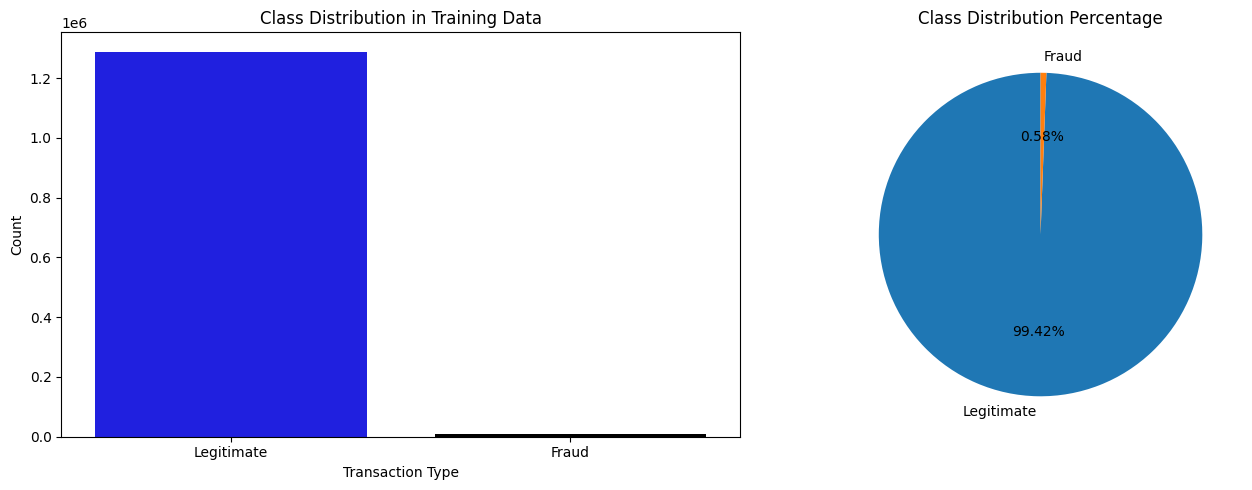


Transaction Amount Analysis:
count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot showing count of each class
sns.countplot(x='is_fraud', data=train_df, palette=['blue', 'black'], ax=axes[0])
axes[0].set_title('Class Distribution in Training Data')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Pie chart showing percentage distribution
axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
             startangle=90)
axes[1].set_title('Class Distribution Percentage')

plt.tight_layout()
plt.show()

# Analyze transaction amount distribution
print("\nTransaction Amount Analysis:")
print(train_df['amt'].describe())


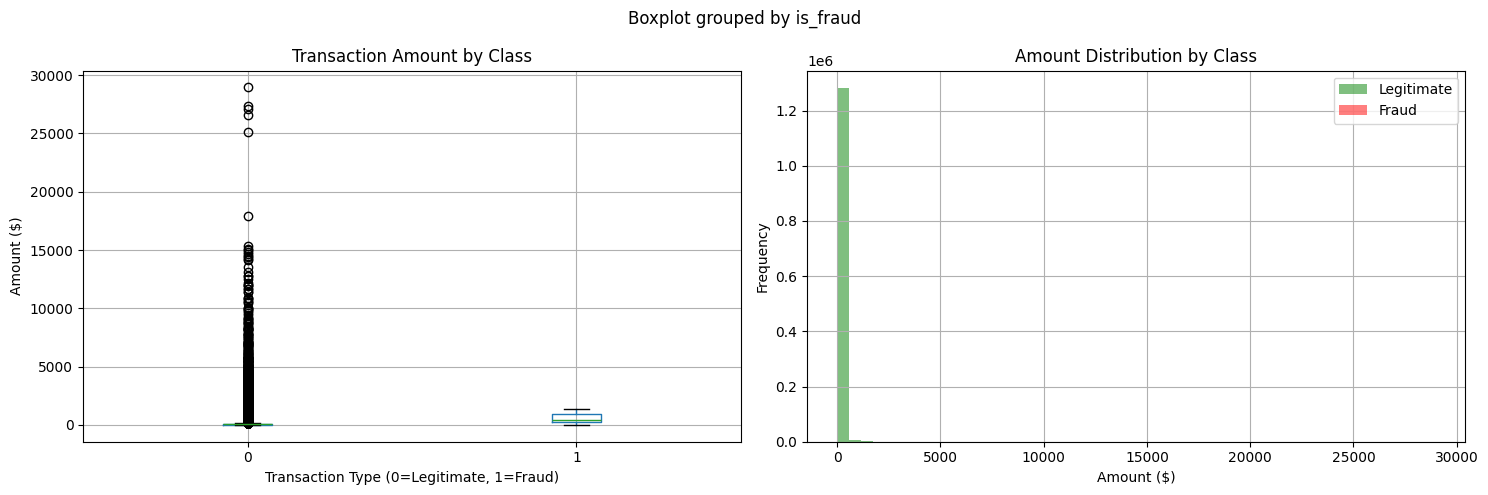

In [ ]:
import plotly.express as px

# Interactive Box Plot comparing amounts
fig1 = px.box(train_df, x="is_fraud", y="amt", 
             color="is_fraud",
             title="Interactive Transaction Amount by Class",
             labels={"is_fraud": "Transaction Type (0=Legitimate, 1=Fraud)", "amt": "Amount ($)"})
fig1.show()

# Interactive Histogram showing amount distribution
fig2 = px.histogram(train_df, x="amt", color="is_fraud", 
                   title="Interactive Amount Distribution by Class",
                   labels={"amt": "Amount ($)"},
                   opacity=0.7)
fig2.show()

In [ ]:
# Top 10 merchant categories
print("\nTop 10 Transaction Categories:")
print(train_df['category'].value_counts().head(10))

# Top 10 merchants
print("\nTop 10 Merchants:")
print(train_df['merchant'].value_counts().head(10))


Top 10 Transaction Categories:
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
Name: count, dtype: int64

Top 10 Merchants:
merchant
fraud_Kilback LLC                   4403
fraud_Cormier LLC                   3649
fraud_Schumm PLC                    3634
fraud_Kuhn LLC                      3510
fraud_Boyer PLC                     3493
fraud_Dickinson Ltd                 3434
fraud_Cummerata-Jones               2736
fraud_Kutch LLC                     2734
fraud_Olson, Becker and Koch        2723
fraud_Stroman, Hudson and Erdman    2721
Name: count, dtype: int64



Fraud Rate by Category:
               Fraud_Count  Total_Transactions  Fraud_Rate
category                                                  
shopping_net          1713               97543    0.017561
misc_net               915               63287    0.014458
grocery_pos           1743              123638    0.014098
shopping_pos           843              116672    0.007225
gas_transport          618              131659    0.004694
misc_pos               250               79655    0.003139
grocery_net            134               45452    0.002948
travel                 116               40507    0.002864
entertainment          233               94014    0.002478
personal_care          220               90758    0.002424


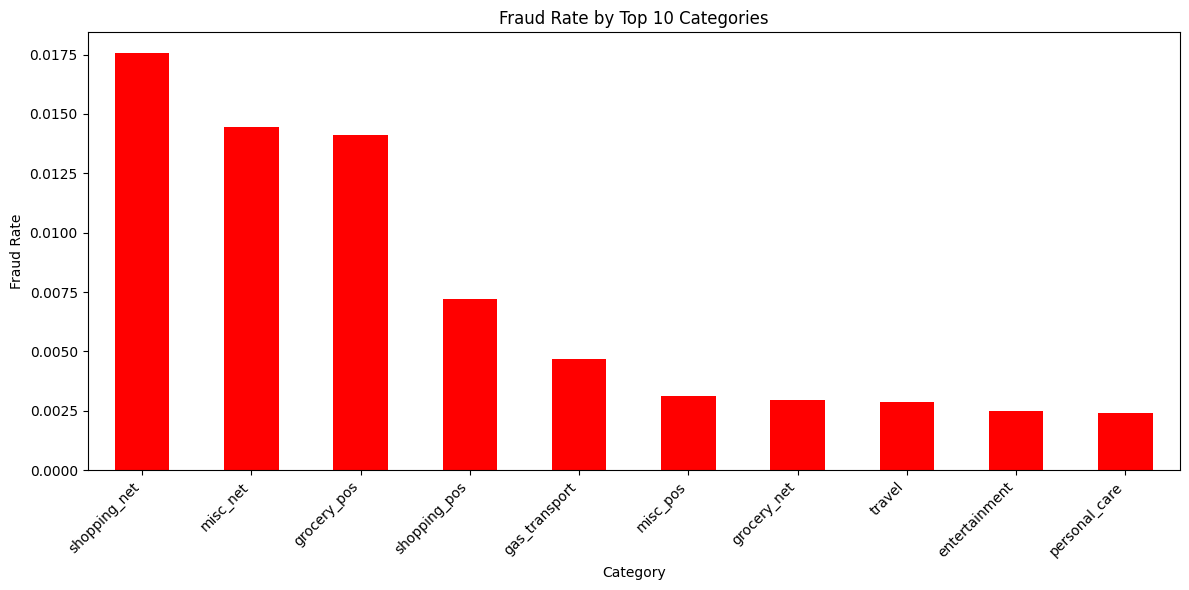

In [ ]:
print("\nFraud Rate by Category:")
fraud_by_category = train_df.groupby('category')['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_category.columns = ['Fraud_Count', 'Total_Transactions', 'Fraud_Rate']
fraud_by_category = fraud_by_category.sort_values('Fraud_Rate', ascending=False)
print(fraud_by_category.head(10))

# Visualize fraud rate by category
plt.figure(figsize=(12, 6))
fraud_by_category.head(10)['Fraud_Rate'].plot(kind='bar', color='red')
plt.title('Fraud Rate by Top 10 Categories')
plt.xlabel('Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Fraud Rate by Amount Range:
  Amount_Range  Total_Transactions  Fraud_Rate_Pct
0        0-100             1061728        0.155595
1      101-250              196488        0.124181
2      251-500               22828        8.594708
3     501-1000               11694       23.071661
4    1001-5000                3801       24.993423
5     5001-10k                 102        0.000000
6         10k+                  34        0.000000


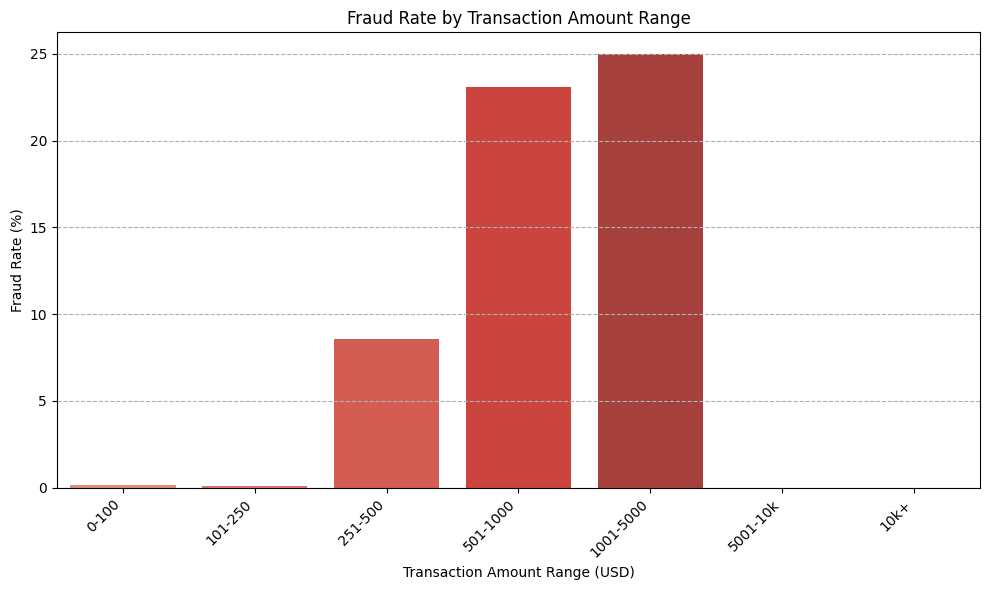

In [ ]:
# Created new feature: Amount Bins
# Defined the bin edges (in USD)
bins = [0, 100, 250, 500, 1000, 5000, 10000, 50000]
labels = ['0-100', '101-250', '251-500', '501-1000', '1001-5000', '5001-10k', '10k+']

# Used pandas.cut to create the bins
train_df['amount_bin'] = pd.cut(train_df['amt'], bins=bins, labels=labels, right=False)

# Grouped by the new bins and calculated fraud rate
fraud_by_amount = train_df.groupby('amount_bin')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
fraud_by_amount.columns = ['Amount_Range', 'Fraud_Count', 'Total_Transactions', 'Fraud_Rate']

# Converted Fraud_Rate to percentage for better readability
fraud_by_amount['Fraud_Rate_Pct'] = fraud_by_amount['Fraud_Rate'] * 100

print("\nFraud Rate by Amount Range:")
print(fraud_by_amount[['Amount_Range', 'Total_Transactions', 'Fraud_Rate_Pct']].head(8))

# Visualized the Fraud Rate by Amount Range
plt.figure(figsize=(10, 6))
sns.barplot(x='Amount_Range', y='Fraud_Rate_Pct', data=fraud_by_amount, palette='Reds_d', order=labels)
plt.title('Fraud Rate by Transaction Amount Range')
plt.xlabel('Transaction Amount Range (USD)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Check unique values for key columns
print("\nUnique Value Counts:")
print(f"Unique merchants: {train_df['merchant'].nunique()}")
print(f"Unique categories: {train_df['category'].nunique()}")
print(f"Unique states: {train_df['state'].nunique()}")
print(f"Unique cities: {train_df['city'].nunique()}")
print(f"Unique jobs: {train_df['job'].nunique()}")


Unique Value Counts:
Unique merchants: 693
Unique categories: 14
Unique states: 51
Unique cities: 894
Unique jobs: 494


In [ ]:
print("\nData Types Overview:")
print(train_df.dtypes)


Data Types Overview:
Unnamed: 0                  int64
trans_date_trans_time      object
cc_num                      int64
merchant                   object
category                   object
amt                       float64
first                      object
last                       object
gender                     object
street                     object
city                       object
state                      object
zip                         int64
lat                       float64
long                      float64
city_pop                    int64
job                        object
dob                        object
trans_num                  object
unix_time                   int64
merch_lat                 float64
merch_long                float64
is_fraud                    int64
amount_bin               category
dtype: object


**STAGE 2:** **FEATURE ENGINEERING**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2

In [ ]:
print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (1296675, 24)
Testing data shape: (555719, 23)


In [ ]:
train_processed = train_df.copy()
test_processed = test_df.copy()

**Creating Temporal Features:**

In [ ]:
#Feature 1:extracts the time from the from the date and time to find if the transaction is legitimate or fraud.
train_processed['trans_hour'] = train_processed['trans_datetime'].dt.hour
test_processed['trans_hour'] = test_processed['trans_datetime'].dt.hour

In [ ]:
#Feature 2:Extracts the day of the week to check in which day the transaction has happened.
train_processed['trans_day_of_week'] = train_processed['trans_datetime'].dt.dayofweek
test_processed['trans_day_of_week'] = test_processed['trans_datetime'].dt.dayofweek

In [ ]:
#feature 3: If the particular transaction has happened in a week or no ( 0 OR 1)
train_processed['is_weekend'] = (train_processed['trans_day_of_week'] >= 5).astype(int)
test_processed['is_weekend'] = (test_processed['trans_day_of_week'] >= 5).astype(int)

In [ ]:
#Feature 4: Extract the day of the the moth (1-31) in which the transaction has happened
train_processed['trans_day'] = train_processed['trans_datetime'].dt.day
test_processed['trans_day'] = test_processed['trans_datetime'].dt.day

In [ ]:
#feature 5: Which month the transaction has happened
train_processed['trans_month'] = train_processed['trans_datetime'].dt.month
test_processed['trans_month'] = test_processed['trans_datetime'].dt.month

In [ ]:
# Feature 6: Converts the raw transaction date string into a proper datetime object so we can extract time details.
train_processed['trans_datetime'] = pd.to_datetime(train_processed['trans_date_trans_time'])
test_processed['trans_datetime'] = pd.to_datetime(test_processed['trans_date_trans_time'])


**Location Feature:**

In [ ]:
#Feature 6: The distance from home where the transaction has taken place if it is near to home or far away from the home
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Calculate differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Apply Haversine formula
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    # Radius of Earth in miles
    radius_earth_miles = 3959

    # Calculate distance
    distance = radius_earth_miles * c

    return distance

In [ ]:
train_processed['distance_from_home'] = train_processed.apply(
    lambda row: haversine_distance(
        row['lat'], row['long'],           # Customer coordinates
        row['merch_lat'], row['merch_long'] # Merchant coordinates
    ), axis=1
)

test_processed['distance_from_home'] = test_processed.apply(
    lambda row: haversine_distance(
        row['lat'], row['long'],
        row['merch_lat'], row['merch_long']
    ), axis=1
)


In [ ]:
print("- distance_from_home: Distance in miles between customer and merchant")

# Display sample of new features
print(train_processed[['trans_hour', 'trans_day_of_week', 'is_weekend',
                        'distance_from_home']].head(10))

# Check for any NaN values in new features
new_features = ['trans_hour', 'trans_day_of_week', 'is_weekend', 'trans_day',
                'trans_month', 'distance_from_home']
print(train_processed[new_features].isnull().sum())

# Basic statistics of distance feature
print("\nDistance from home statistics:")
print(train_processed['distance_from_home'].describe())

# Analyze distance by fraud status
print("Legitimate transactions - Average distance:",
      train_processed[train_processed['is_fraud']==0]['distance_from_home'].mean())
print("Fraudulent transactions - Average distance:",
      train_processed[train_processed['is_fraud']==1]['distance_from_home'].mean())

- distance_from_home: Distance in miles between customer and merchant
   trans_hour  trans_day_of_week  is_weekend  distance_from_home
0           0                  1           0           48.841277
1           0                  1           0           18.774133
2           0                  1           0           67.240289
3           0                  1           0           59.452256
4           0                  1           0           48.194498
5           0                  1           0           53.393147
6           0                  1           0           73.400752
7           0                  1           0            7.933487
8           0                  1           0           15.703325
9           0                  1           0           46.032619
trans_hour            0
trans_day_of_week     0
is_weekend            0
trans_day             0
trans_month           0
distance_from_home    0
dtype: int64

Distance from home statistics:
count    1.296675e+06
mean

**Creating customer spending Features:**

In [ ]:
#Feature 7: calulates the each of the customers average amount in spending.
customer_avg_amount = train_processed.groupby('cc_num')['amt'].mean().to_dict()
train_processed['customer_avg_amt'] = train_processed['cc_num'].map(customer_avg_amount)
overall_avg = train_processed['amt'].mean()
test_processed['customer_avg_amt'] = test_processed['cc_num'].map(customer_avg_amount).fillna(overall_avg)

#Feature 8:  How much does the current transaction of the customer differ from the customers average.
train_processed['amt_deviation'] = train_processed['amt'] - train_processed['customer_avg_amt']
test_processed['amt_deviation'] = test_processed['amt'] - test_processed['customer_avg_amt']

#Feature 9:  How much is the deviate in ratio
train_processed['amt_ratio'] = train_processed['amt'] / (train_processed['customer_avg_amt'] + 0.01)
test_processed['amt_ratio'] = test_processed['amt'] / (test_processed['customer_avg_amt'] + 0.01)

In [ ]:
category_avg_amount = train_processed.groupby('category')['amt'].mean().to_dict()

#Feature 10:  calculates the average amount for each of the categories in the datset
train_processed['category_avg_amt'] = train_processed['category'].map(category_avg_amount)
test_processed['category_avg_amt'] = test_processed['category'].map(category_avg_amount)

# Feature 11: Amount Deviation from Category Average
# Is this transaction amount unusual for this type of purchase?
# Example: $500 is normal for electronics but suspicious for gas
train_processed['amt_deviation_from_category'] = train_processed['amt'] - train_processed['category_avg_amt']
test_processed['amt_deviation_from_category'] = test_processed['amt'] - test_processed['category_avg_amt']

In [ ]:
train_sorted = train_processed.sort_values(['cc_num', 'unix_time'])

# Feature 12: Time Since Last Transaction (in hours)
# Calculate hours elapsed since customer's previous transaction
# Very short gaps are suspicious
train_sorted['time_since_last_trans'] = train_sorted.groupby('cc_num')['unix_time'].diff()

# Convert from seconds to hours
# unix_time is in seconds, divide by 3600 to get hours
train_sorted['hours_since_last_trans'] = train_sorted['time_since_last_trans'] / 3600

# For first transaction of each customer, fill with median value
median_gap = train_sorted['hours_since_last_trans'].median()
train_sorted['hours_since_last_trans'] = train_sorted['hours_since_last_trans'].fillna(median_gap)

# Merge back to original dataframe
train_processed = train_sorted.copy()

# For test data, we cannot calculate this accurately without full history
# Use a placeholder value (median from training)
test_processed['hours_since_last_trans'] = median_gap

In [ ]:
merchant_customer_counts = train_processed.groupby(['cc_num', 'merchant']).size().to_dict()

# For each transaction, count previous visits to this merchant
# This is simplified - in production, you'd calculate cumulative count
def get_merchant_familiarity(row):
    key = (row['cc_num'], row['merchant'])
    return merchant_customer_counts.get(key, 0)

train_processed['merchant_visit_count'] = train_processed.apply(get_merchant_familiarity, axis=1)

# For test data, use same mapping
test_processed['merchant_visit_count'] = test_processed.apply(
    lambda row: merchant_customer_counts.get((row['cc_num'], row['merchant']), 0),
    axis=1
)

In [ ]:
#how many times did the merchant visit the particular place
#is the merchant visiting the place for the first time
train_processed['is_new_merchant'] = (train_processed['merchant_visit_count'] == 0).astype(int)
test_processed['is_new_merchant'] = (test_processed['merchant_visit_count'] == 0).astype(int)

In [ ]:
# Age groups have different spending patterns
train_processed['dob_datetime'] = pd.to_datetime(train_processed['dob'])
test_processed['dob_datetime'] = pd.to_datetime(test_processed['dob'])

# Calculate age at time of transaction
train_processed['age'] = (train_processed['trans_datetime'] - train_processed['dob_datetime']).dt.days / 365.25
test_processed['age'] = (test_processed['trans_datetime'] - test_processed['dob_datetime']).dt.days / 365.25

# Round to integer
train_processed['age'] = train_processed['age'].round().astype(int)
test_processed['age'] = test_processed['age'].round().astype(int)

# Feature 10: Gender Encoding
# Convert gender (M/F) to numeric (0/1)
train_processed['gender_encoded'] = (train_processed['gender'] == 'M').astype(int)
test_processed['gender_encoded'] = (test_processed['gender'] == 'M').astype(int)


In [ ]:
# Displaying sample of new pattern features
print("\nSample of newly created pattern features:")
sample_cols = ['amt', 'customer_avg_amt', 'amt_deviation', 'amt_ratio',
               'hours_since_last_trans', 'merchant_visit_count', 'age']
print(train_processed[sample_cols].head(10))

# Check for any NaN values in new features
print("\nChecking for missing values in new pattern features:")
pattern_features = ['customer_avg_amt', 'amt_deviation', 'amt_ratio',
                    'category_avg_amt', 'amt_deviation_from_category',
                    'hours_since_last_trans', 'merchant_visit_count',
                    'is_new_merchant', 'age', 'gender_encoded']
print(train_processed[pattern_features].isnull().sum())


Sample of newly created pattern features:
         amt  customer_avg_amt  amt_deviation  amt_ratio  \
1017    7.27         56.023366     -48.753366   0.129744   
2724   52.94         56.023366      -3.083366   0.944794   
2726   82.08         56.023366      26.056634   1.464841   
2882   34.79         56.023366     -21.233366   0.620880   
2907   27.18         56.023366     -28.843366   0.485068   
4135    6.87         56.023366     -49.153366   0.122606   
4337    8.43         56.023366     -47.593366   0.150446   
5467  117.11         56.023366      61.086634   2.090005   
6027   26.74         56.023366     -29.283366   0.477216   
6273  105.20         56.023366      49.176634   1.877453   

      hours_since_last_trans  merchant_visit_count  age  
1017                4.607500                     3   33  
2724               19.961667                     7   33  
2726                0.044167                     9   33  
2882                3.843889                     3   33  
2907  

In [ ]:
# Convert transaction category into separate binary columns (one-hot encoding)
# Each category (gas, grocery, shopping) becomes its own column with 1 or 0
if 'category' in train_processed.columns:
    print(f"Number of unique categories: {train_processed['category'].nunique()}")

    category_encoded_train = pd.get_dummies(train_processed['category'], prefix='cat')
    category_encoded_test = pd.get_dummies(test_processed['category'], prefix='cat')

    category_encoded_train, category_encoded_test = category_encoded_train.align(
        category_encoded_test, join='left', axis=1, fill_value=0
    )

    train_processed = pd.concat([train_processed, category_encoded_train], axis=1)
    test_processed = pd.concat([test_processed, category_encoded_test], axis=1)

    print(f"Created {len(category_encoded_train.columns)} category columns")

Number of unique categories: 14
Created 14 category columns


In [ ]:
# Replace merchant names with their historical fraud rates (target encoding)
# Merchants with more fraud history get higher values, helping model identify risky merchants
overall_fraud_rate = train_processed['is_fraud'].mean()

if 'merchant' in train_processed.columns and 'merchant_encoded' not in train_processed.columns:
    merchant_fraud_rate = train_processed.groupby('merchant')['is_fraud'].mean().to_dict()

    train_processed['merchant_encoded'] = train_processed['merchant'].map(merchant_fraud_rate)
    test_processed['merchant_encoded'] = test_processed['merchant'].map(merchant_fraud_rate)

    train_processed['merchant_encoded'] = train_processed['merchant_encoded'].fillna(overall_fraud_rate)
    test_processed['merchant_encoded'] = test_processed['merchant_encoded'].fillna(overall_fraud_rate)

    print(f"Merchant encoding complete. Unique merchants: {len(merchant_fraud_rate)}")

Merchant encoding complete. Unique merchants: 693


In [ ]:
# Replace state names with their fraud rates to capture geographic fraud patterns
# Some states have higher fraud rates, this encoding helps model learn regional risks
if 'state' in train_processed.columns and 'state_encoded' not in train_processed.columns:
    state_fraud_rate = train_processed.groupby('state')['is_fraud'].mean().to_dict()

    train_processed['state_encoded'] = train_processed['state'].map(state_fraud_rate)
    test_processed['state_encoded'] = test_processed['state'].map(state_fraud_rate)

    train_processed['state_encoded'] = train_processed['state_encoded'].fillna(overall_fraud_rate)
    test_processed['state_encoded'] = test_processed['state_encoded'].fillna(overall_fraud_rate)

    print(f"State encoding complete. Unique states: {len(state_fraud_rate)}")

State encoding complete. Unique states: 51


In [ ]:
# Replace city names with fraud rates to capture urban vs rural fraud patterns
# Different cities have different fraud levels based on population and crime rates
if 'city' in train_processed.columns and 'city_encoded' not in train_processed.columns:
    city_fraud_rate = train_processed.groupby('city')['is_fraud'].mean().to_dict()

    train_processed['city_encoded'] = train_processed['city'].map(city_fraud_rate)
    test_processed['city_encoded'] = test_processed['city'].map(city_fraud_rate)

    train_processed['city_encoded'] = train_processed['city_encoded'].fillna(overall_fraud_rate)
    test_processed['city_encoded'] = test_processed['city_encoded'].fillna(overall_fraud_rate)

    print(f"City encoding complete. Unique cities: {len(city_fraud_rate)}")

City encoding complete. Unique cities: 894


In [ ]:
# Replace job titles with fraud rates as certain professions may be targeted more by fraudsters
# This helps identify if specific occupations have higher fraud vulnerability
if 'job' in train_processed.columns and 'job_encoded' not in train_processed.columns:
    job_fraud_rate = train_processed.groupby('job')['is_fraud'].mean().to_dict()

    train_processed['job_encoded'] = train_processed['job'].map(job_fraud_rate)
    test_processed['job_encoded'] = test_processed['job'].map(job_fraud_rate)

    train_processed['job_encoded'] = train_processed['job_encoded'].fillna(overall_fraud_rate)
    test_processed['job_encoded'] = test_processed['job_encoded'].fillna(overall_fraud_rate)

    print(f"Job encoding complete. Unique jobs: {len(job_fraud_rate)}")

Job encoding complete. Unique jobs: 494


In [ ]:
# Remove columns that don't help prediction like personal identifiers and raw text data
# Keep only numeric features that the machine learning model can process
columns_to_drop = [
    'Unnamed: 0', 'trans_num', 'cc_num',
    'merchant', 'category', 'state', 'city', 'job', 'gender',
    'first', 'last', 'street', 'zip',
    'trans_date_trans_time', 'trans_datetime', 'dob', 'dob_datetime',
    'lat', 'long', 'merch_lat', 'merch_long',
    'time_since_last_trans'
]

columns_to_drop_train = [col for col in columns_to_drop if col in train_processed.columns]
columns_to_drop_test = [col for col in columns_to_drop if col in test_processed.columns]

train_processed = train_processed.drop(columns=columns_to_drop_train)
test_processed = test_processed.drop(columns=columns_to_drop_test)

print(f"Dropped {len(columns_to_drop_train)} columns from training")
print(f"Dropped {len(columns_to_drop_test)} columns from testing")

Dropped 22 columns from training
Dropped 21 columns from testing


In [ ]:
# Separate features (X) from target variable (y) for model training
# Ensure train and test have matching columns to avoid errors during prediction
feature_columns = [col for col in train_processed.columns if col != 'is_fraud']
feature_columns = [col for col in feature_columns if col in test_processed.columns]

X_train = train_processed[feature_columns]
y_train = train_processed['is_fraud']

X_test = test_processed[feature_columns]
y_test = test_processed['is_fraud']

print(f"Features after alignment: {len(feature_columns)}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Features after alignment: 37
X_train: (1296675, 37)
X_test: (555719, 37)


In [ ]:
# Fill any remaining missing values with 0 to prevent model training errors
# Missing values can occur from encoding or feature engineering steps
print(f"Missing values in training: {X_train.isnull().sum().sum()}")
print(f"Missing values in testing: {X_test.isnull().sum().sum()}")

if X_train.isnull().sum().sum() > 0:
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
    print("Missing values filled with 0")

Missing values in training: 0
Missing values in testing: 0


In [ ]:
print("Summary of the final dataset: ")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Columns present in the dataset")
print(list(X_train.columns))

Summary of the final dataset: 
X_train shape: (1296675, 37)
X_test shape: (555719, 37)
Number of features: 37
Columns present in the dataset
['amt', 'city_pop', 'unix_time', 'trans_hour', 'trans_day_of_week', 'is_weekend', 'trans_day', 'trans_month', 'distance_from_home', 'customer_avg_amt', 'amt_deviation', 'amt_ratio', 'category_avg_amt', 'amt_deviation_from_category', 'hours_since_last_trans', 'merchant_visit_count', 'is_new_merchant', 'age', 'gender_encoded', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel', 'merchant_encoded', 'state_encoded', 'city_encoded', 'job_encoded']


**STAGE 3 : MODEL TRAINING**

In [ ]:
# Extract temporal features from transaction datetime to identify suspicious timing patterns
# Frauds often occur at unusual hours (late night) or specific days when victims are less vigilant
train_df['trans_datetime'] = pd.to_datetime(train_df['trans_date_trans_time'])
test_df['trans_datetime'] = pd.to_datetime(test_df['trans_date_trans_time'])

train_df['trans_hour'] = train_df['trans_datetime'].dt.hour
test_df['trans_hour'] = test_df['trans_datetime'].dt.hour

train_df['trans_day_of_week'] = train_df['trans_datetime'].dt.dayofweek
test_df['trans_day_of_week'] = test_df['trans_datetime'].dt.dayofweek

train_df['is_weekend'] = (train_df['trans_day_of_week'] >= 5).astype(int)
test_df['is_weekend'] = (test_df['trans_day_of_week'] >= 5).astype(int)

train_df['trans_month'] = train_df['trans_datetime'].dt.month
test_df['trans_month'] = test_df['trans_datetime'].dt.month

print("Time features created")

Time features created


In [ ]:
# Calculate geographic distance between customer home and merchant location using Haversine formula
# Large distances are highly suspicious as fraudsters use stolen cards far from victim's location
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return 3959 * c

train_df['distance_from_home'] = train_df.apply(
    lambda row: haversine_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1
)
test_df['distance_from_home'] = test_df.apply(
    lambda row: haversine_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1
)

print("Distance feature created")

Distance feature created


In [ ]:
# Analyze each customer's typical spending behavior to detect unusual transaction amounts
# Fraudsters typically make larger purchases than the victim's normal pattern
customer_avg = train_df.groupby('cc_num')['amt'].mean().to_dict()
overall_avg = train_df['amt'].mean()

train_df['customer_avg_amt'] = train_df['cc_num'].map(customer_avg)
test_df['customer_avg_amt'] = test_df['cc_num'].map(customer_avg).fillna(overall_avg)

train_df['amt_deviation'] = train_df['amt'] - train_df['customer_avg_amt']
test_df['amt_deviation'] = test_df['amt'] - test_df['customer_avg_amt']

train_df['amt_ratio'] = train_df['amt'] / (train_df['customer_avg_amt'] + 0.01)
test_df['amt_ratio'] = test_df['amt'] / (test_df['customer_avg_amt'] + 0.01)

category_avg = train_df.groupby('category')['amt'].mean().to_dict()
train_df['category_avg_amt'] = train_df['category'].map(category_avg)
test_df['category_avg_amt'] = test_df['category'].map(category_avg)

print("Spending features created")

Spending features created


In [ ]:
# Track customer familiarity with merchants to identify first-time or unusual merchant usage
# Transactions at new merchants are riskier as fraudsters test stolen cards at unfamiliar locations
merchant_counts = train_df.groupby(['cc_num', 'merchant']).size().to_dict()

train_df['merchant_visit_count'] = train_df.apply(
    lambda row: merchant_counts.get((row['cc_num'], row['merchant']), 0), axis=1
)
test_df['merchant_visit_count'] = test_df.apply(
    lambda row: merchant_counts.get((row['cc_num'], row['merchant']), 0), axis=1
)

train_df['is_new_merchant'] = (train_df['merchant_visit_count'] == 0).astype(int)
test_df['is_new_merchant'] = (test_df['merchant_visit_count'] == 0).astype(int)

print("Merchant features created")

Merchant features created


In [ ]:
# Extract demographic features as different age groups and genders show different fraud patterns
# These features help model understand target demographics that fraudsters prefer to attack
train_df['dob_datetime'] = pd.to_datetime(train_df['dob'])
test_df['dob_datetime'] = pd.to_datetime(test_df['dob'])

train_df['age'] = ((train_df['trans_datetime'] - train_df['dob_datetime']).dt.days / 365.25).round().astype(int)
test_df['age'] = ((test_df['trans_datetime'] - test_df['dob_datetime']).dt.days / 365.25).round().astype(int)

train_df['gender_encoded'] = (train_df['gender'] == 'M').astype(int)
test_df['gender_encoded'] = (test_df['gender'] == 'M').astype(int)

print("Age and gender features created")

Age and gender features created


In [ ]:
# Convert transaction category (gas, grocery, shopping) into binary columns using one-hot encoding
# Each category has different fraud rates, so model learns which categories are riskier
cat_train = pd.get_dummies(train_df['category'], prefix='cat')
cat_test = pd.get_dummies(test_df['category'], prefix='cat')
cat_train, cat_test = cat_train.align(cat_test, join='left', axis=1, fill_value=0)

train_df = pd.concat([train_df, cat_train], axis=1)
test_df = pd.concat([test_df, cat_test], axis=1)

print("Category encoded")

Category encoded


In [ ]:
# Replace merchant names with their historical fraud rates using target encoding
# Merchants with higher fraud history get higher encoded values, helping model identify risky merchants
merchant_fraud_rate = train_df.groupby('merchant')['is_fraud'].mean().to_dict()
overall_fraud_rate = train_df['is_fraud'].mean()

train_df['merchant_encoded'] = train_df['merchant'].map(merchant_fraud_rate).fillna(overall_fraud_rate)
test_df['merchant_encoded'] = test_df['merchant'].map(merchant_fraud_rate).fillna(overall_fraud_rate)

print("Merchant encoded")

Merchant encoded


In [ ]:
# Remove unnecessary columns that don't help prediction (personal info, IDs, raw coordinates)
# Keep only numeric features and the target variable for model training
drop_cols = ['Unnamed: 0', 'trans_num', 'cc_num', 'merchant', 'category',
             'state', 'city', 'job', 'gender', 'first', 'last', 'street', 'zip',
             'trans_date_trans_time', 'trans_datetime', 'dob', 'dob_datetime',
             'lat', 'long', 'merch_lat', 'merch_long']

train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

feature_cols = [col for col in train_df.columns if col != 'is_fraud' and col in test_df.columns]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['is_fraud']
X_test = test_df[feature_cols].fillna(0)
y_test = test_df['is_fraud']

print(f"Final data: {X_train.shape[1]} features")

Final data: 31 features


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve
import xgboost as xgb
import pickle
from math import radians, sin, cos, sqrt, atan2
# Balance the dataset by creating synthetic fraud samples using SMOTE algorithm
# This helps model learn fraud patterns better since original data has only 0.5% frauds
smote = SMOTE(sampling_strategy=0.2, random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")

After SMOTE: 1547002 samples


In [ ]:
# Train XGBoost classifier with 500 trees and depth 10 for maximum fraud detection performance
# Uses GPU acceleration and optimized hyperparameters for handling imbalanced fraud data
model = xgb.XGBClassifier(
    device='cuda', tree_method='hist', n_estimators=500, max_depth=10,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=5, gamma=0.1, reg_alpha=0.1, reg_lambda=1.5,
    grow_policy='lossguide', max_leaves=64, random_state=42, n_jobs=-1
)

model.fit(X_train_balanced, y_train_balanced, verbose=False)
print("The training of the model is completed")

The training of the model is completed


In [ ]:
# Find optimal decision threshold to maximize fraud detection (recall) while maintaining precision
# Lower threshold catches more frauds but increases false alarms, we optimize for 88%+ recall
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Default: Caught {tp} frauds, Missed {fn}")

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
thresholds = np.append(thresholds, 1.0)
df = pd.DataFrame({'threshold': thresholds, 'precision': precisions, 'recall': recalls})

recall_88 = df[df['recall'] >= 0.88]
optimal_threshold = recall_88.loc[recall_88['precision'].idxmax(), 'threshold']

y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

print(f"Optimized: Caught {tp_opt} frauds, Missed {fn_opt}")
print(f"Optimal threshold: {optimal_threshold:.4f}")

Default: Caught 1814 frauds, Missed 331
Optimized: Caught 1888 frauds, Missed 257
Optimal threshold: 0.3029


In [ ]:
# Save trained model, feature names, and optimal threshold for deployment in web application
# These files will be loaded by Streamlit app to make real-time fraud predictions
pickle.dump(model, open('fraud_model.pkl', 'wb'))
pickle.dump(feature_cols, open('features.pkl', 'wb'))
pickle.dump(optimal_threshold, open('threshold.pkl', 'wb'))

print("Saved: model, features, threshold")

Saved: model, features, threshold


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives: {tn}")
print(f"False Negatives: {fn}")

Accuracy: 99.72%
Precision: 59.18%
Recall: 88.02%
F1-Score: 0.7078
ROC-AUC: 0.9967

Confusion Matrix:
True Positives: 1888
False Positives: 1302
True Negatives: 552272
False Negatives: 257


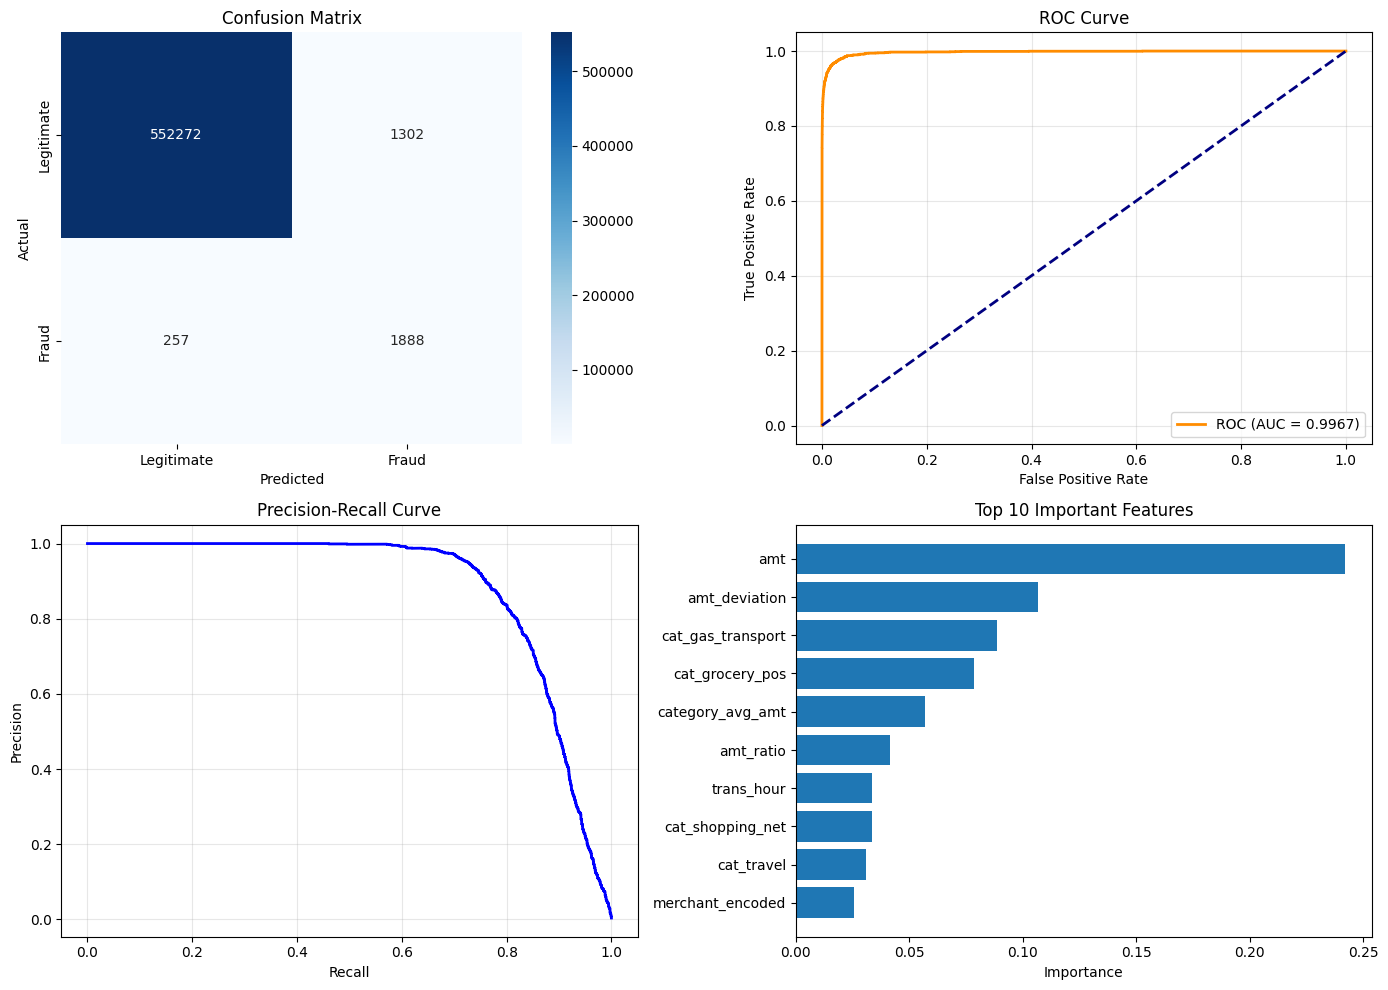

In [ ]:
# MODEL VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import pandas as pd

# Make predictions with optimal threshold
y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)

# Create 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0,0].set_yticklabels(['Legitimate', 'Fraud'])

# 2. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc='lower right')
axes[0,1].grid(alpha=0.3)

# 3. PRECISION-RECALL CURVE
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(recall, precision, color='blue', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].grid(alpha=0.3)

# 4. FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[1,1].barh(range(len(importance_df)), importance_df['importance'])
axes[1,1].set_yticks(range(len(importance_df)))
axes[1,1].set_yticklabels(importance_df['feature'])
axes[1,1].set_xlabel('Importance')
axes[1,1].set_title('Top 10 Important Features')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
# from google.colab import files

# # Download the 3 model files
# files.download('fraud_model.pkl')
# files.download('features.pkl')
# files.download('threshold.pkl')